In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df = pd.read_excel(r'C:\Users\MSI\Desktop\KNN_task\data\titanic3.xls', engine='xlrd')
df.to_csv(r'C:\Users\MSI\Desktop\KNN_task\data\titanic3.csv', index=False)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [2]:
numeric_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
cat_cols = ['sex', 'embarked']

df[numeric_cols].agg(['mean', 'median', 'std', 'count'])#siyahidaki butun emeliyyatlari eyni anda hesabliyir ideal


,pclass,age,sibsp,parch,fare
mean,2.294882,29.881135,0.498854,0.385027,33.295479
median,3.000000,28.000000,0.000000,0.000000,14.454200
std,0.837836,14.413500,1.041658,0.865560,51.758668
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000


In [3]:
df['sex'].value_counts() #her unikal deyerin nece defe tekararlndigni sayir hemin sutundaki
df['embarked'].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [4]:
df['survived'].value_counts(normalize=True)#normalize eliyende sayi yox faizi verir

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64

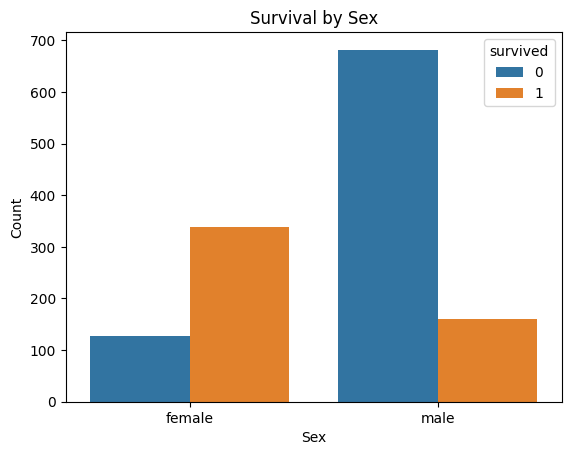

In [5]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()  #qadinnar daha cox sag qalib

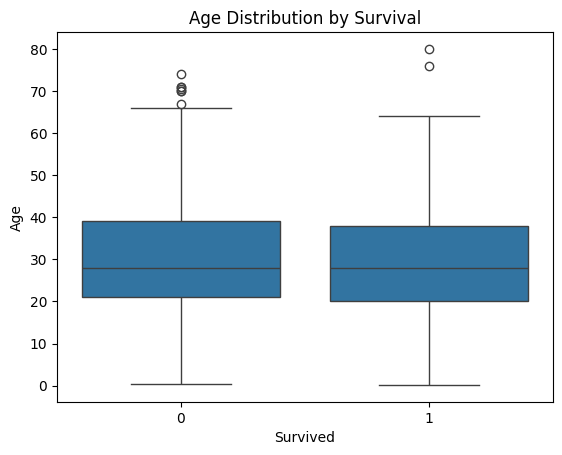

In [6]:
sns.boxplot(x='survived', y='age', data=df)
plt.title('Age Distribution by Survival')
plt.xlabel('Survived') #yas coxda onem dasimiyib
plt.ylabel('Age')
plt.show()

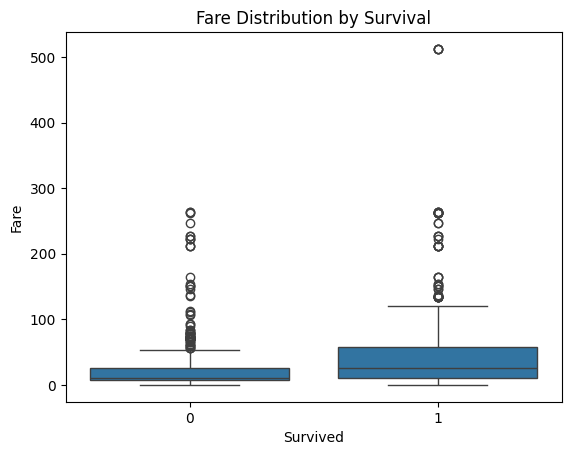

In [7]:
sns.boxplot(x='survived', y='fare', data=df)
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived')#biletin qiymeti tesir elyib teessuf
plt.ylabel('Fare')
plt.show()

In [8]:
df.isnull().sum()#hansi sutunnarda bos degerler var

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [9]:
#bilrikki mean tesirlnir qiymetderden ona gorede biz bos xanaalraa hemin sutun uzre olna mediani yaziriq
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
'''cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df[cols].isnull().sum()'''  #ozum cehck eledim deye

"cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']\ndf[cols].isnull().sum()"

In [10]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0})#encoding elyri cunki bunnarin deyerleri meselen female ve male reqem deyil ama knn ancaq reqemnen isliyecek
df = pd.get_dummies(df, columns=['embarked'], drop_first=False)
df['embarked_C'] = df['embarked_C'].astype(int)
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)
df.head()
df.columns.tolist() #gormekcin

['pclass',
 'survived',
 'name',
 'sex',
 'age',
 'sibsp',
 'parch',
 'ticket',
 'fare',
 'cabin',
 'boat',
 'body',
 'home.dest',
 'embarked_C',
 'embarked_Q',
 'embarked_S']

In [11]:
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 
        'embarked_C', 'embarked_Q', 'embarked_S', 'survived']

df = df[cols]  #final feature matriximiz
print(df.shape)
df.head()

(1309, 10)


,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S,survived
0,1,0,29.0000,0,0,211.3375,0,0,1,1
1,1,1,0.9167,1,2,151.5500,0,0,1,1
2,1,0,2.0000,1,2,151.5500,0,0,1,0
3,1,1,30.0000,1,2,151.5500,0,0,1,0
4,1,0,25.0000,1,2,151.5500,0,0,1,0
